In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [27]:
df = pd.read_csv(r"C:\Users\nitin\OneDrive\Desktop\Ipl_data_analysis\Data\matches.csv")
print(df.head())
print(df.info())

       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0        Kolkat

In [4]:
df = df[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']]


In [5]:
df = df.dropna()

print(df.isnull().sum())

team1            0
team2            0
toss_winner      0
toss_decision    0
venue            0
winner           0
dtype: int64


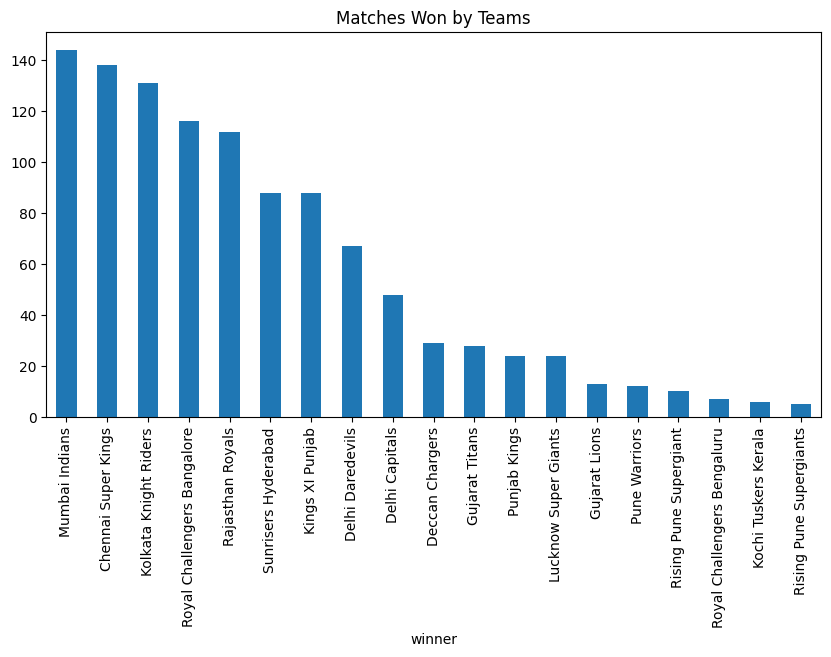

Toss Win → Match Win %: 50.825688073394495


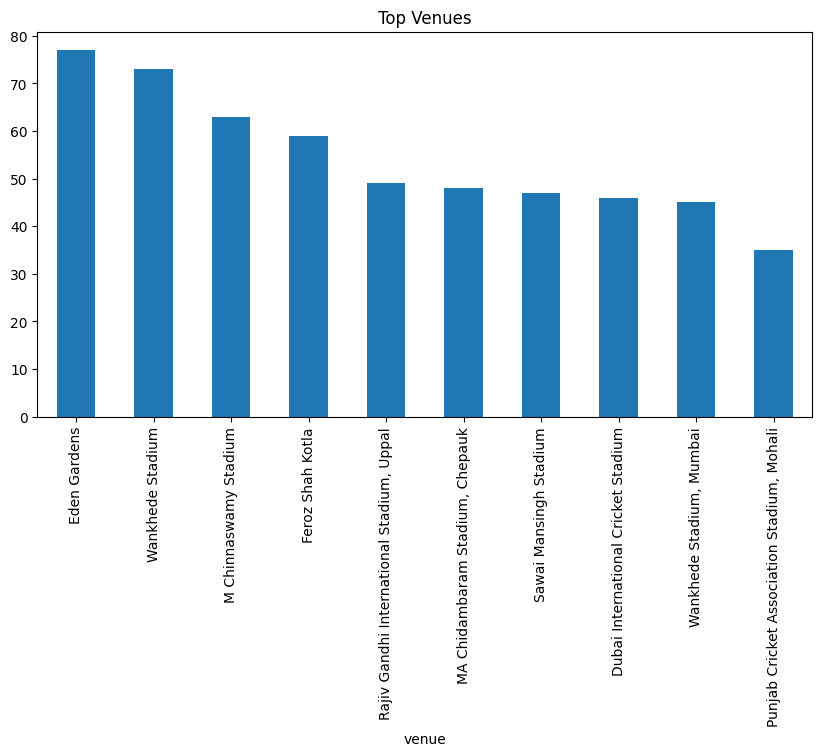

In [6]:
plt.figure(figsize=(10,5))
df['winner'].value_counts().plot(kind='bar')
plt.title("Matches Won by Teams")
plt.show()

toss_win_match_win = df[df['toss_winner'] == df['winner']]
print("Toss Win → Match Win %:", len(toss_win_match_win)/len(df) * 100)

plt.figure(figsize=(10,5))
df['venue'].value_counts().head(10).plot(kind='bar')
plt.title("Top Venues")
plt.show()

In [7]:
df['team1_win'] = df['winner'] == df['team1']
df['team1_win'] = df['team1_win'].astype(int)

In [8]:
le_team = LabelEncoder()
le_venue = LabelEncoder()
le_toss = LabelEncoder()

In [9]:
df['team1'] = le_team.fit_transform(df['team1'])
df['team2'] = le_team.transform(df['team2'])
df['toss_winner'] = le_team.transform(df['toss_winner'])

df['venue'] = le_venue.fit_transform(df['venue'])
df['toss_decision'] = le_toss.fit_transform(df['toss_decision'])

In [10]:
X = df[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']]
y = df['team1_win']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.536697247706422


In [15]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[58 52]
 [49 59]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.53      0.53       110
           1       0.53      0.55      0.54       108

    accuracy                           0.54       218
   macro avg       0.54      0.54      0.54       218
weighted avg       0.54      0.54      0.54       218



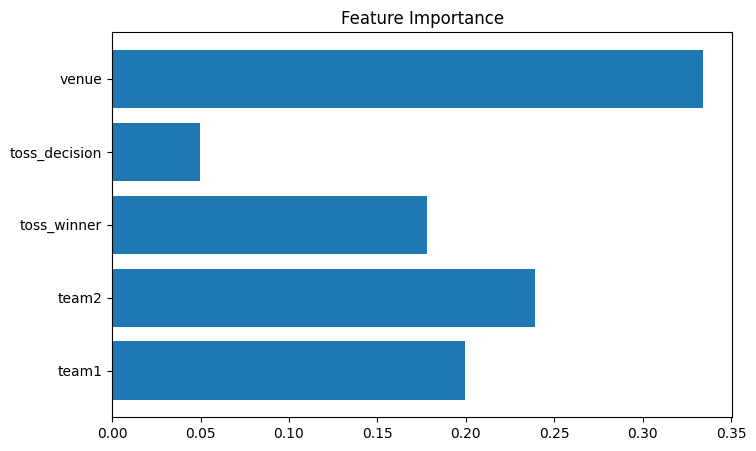

In [16]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [18]:
def predict_winner(team1, team2, toss_winner, toss_decision, venue):
    
    team1_enc = le_team.transform([team1])[0]
    team2_enc = le_team.transform([team2])[0]
    toss_winner_enc = le_team.transform([toss_winner])[0]
    
    venue_enc = le_venue.transform([venue])[0]
    toss_decision_enc = le_toss.transform([toss_decision])[0]

    input_df = pd.DataFrame({
        'team1': [team1_enc],
        'team2': [team2_enc],
        'toss_winner': [toss_winner_enc],
        'toss_decision': [toss_decision_enc],
        'venue': [venue_enc]
    })

    pred = model.predict(input_df)
    
    if pred[0] == 1:
        return team1
    else:
        return team2
    


In [19]:
print(predict_winner(
    "Mumbai Indians",
    "Chennai Super Kings",
    "Mumbai Indians",
    "bat",
    "Wankhede Stadium"
))

Mumbai Indians


In [25]:
print("If CSK wins toss and chooses BAT:")
print(predict_winner(
    "Mumbai Indians",
    "Chennai Super Kings",
    "Chennai Super Kings",
    "bat",
    "MA Chidambaram Stadium"
))

print("\nIf CSK wins toss and chooses FIELD:")
print(predict_winner(
    "Royal Challengers Bangalore",
    "Chennai Super Kings",
    "Royal Challengers Bangalore",
    "field",
    "MA Chidambaram Stadium"
))

If CSK wins toss and chooses BAT:
Mumbai Indians

If CSK wins toss and chooses FIELD:
Chennai Super Kings


In [23]:
df.head()

,team1,team2,toss_winner,toss_decision,venue,winner,team1_win
0,16,8,16,1,23,Kolkata Knight Riders,0
1,6,0,0,0,40,Chennai Super Kings,0
2,3,13,13,0,16,Delhi Daredevils,1
3,10,16,10,0,55,Royal Challengers Bangalore,0
4,8,1,1,0,14,Kolkata Knight Riders,1


In [26]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(le_team, open("le_team.pkl", "wb"))
pickle.dump(le_venue, open("le_venue.pkl", "wb"))
pickle.dump(le_toss, open("le_toss.pkl", "wb"))